# Course 1: Foundations of Deep Learning and Neural Networks

## Complete Summary with Theory, Math, and Practice

This notebook covers the foundational concepts of deep learning — from the AI landscape through CNNs and essential training methodologies.

---

## Table of Contents
1. [The AI Landscape and ML Fundamentals](#ai-landscape)
2. [Neural Networks: Architecture and Learning](#neural-networks)
3. [Gradient Descent Deep Dive](#gradient-descent)
4. [Backpropagation Explained](#backpropagation)
5. [Convolutional Neural Networks (CNNs)](#cnns)
6. [Training Deep Networks: Strategies](#training-strategies)
7. [Seminal CNN Architectures](#architectures)

---

<a name="ai-landscape"></a>
## 1. The AI Landscape and Machine Learning Fundamentals

### Evolution of Artificial Intelligence

```
Symbolic AI (1950s-1980s) → Expert Systems (1980s-1990s) → Machine Learning (1990s-2000s) → Deep Learning (2010s-present)
```

| Era | Approach | Limitation |
|-----|----------|------------|
| **Symbolic AI** | Hand-crafted rules and logic | Doesn't scale; brittle |
| **Expert Systems** | Knowledge bases from human experts | Expensive to build; can't learn |
| **Classical ML** | Feature engineering + shallow models | Manual feature extraction |
| **Deep Learning** | End-to-end feature learning from raw data | Needs large data and compute |

### Types of Machine Learning

| Type | Description | Examples |
|------|-------------|---------|
| **Supervised** | Learn input→output mapping from labeled data | Image classification, regression |
| **Unsupervised** | Find structure in unlabeled data | Clustering, dimensionality reduction |
| **Reinforcement** | Learn via reward/penalty signals | Game playing, robotics |

### Why Deep Learning Now?

Three converging factors:
1. **Data**: The internet created massive labeled datasets (ImageNet: 14M images)
2. **Compute**: GPUs enable parallelized matrix operations
3. **Algorithms**: Better activations (ReLU), regularization (Dropout), normalization (BatchNorm)

### The Data-Centric Paradigm

> *"More data beats a clever algorithm; better data beats more data."*

- Model accuracy is **bounded by data quality**
- Garbage in → garbage out
- Data augmentation, cleaning, and curation are first-class engineering tasks

<a name="neural-networks"></a>
## 2. Neural Networks: Architecture and Learning Mechanisms

### Biological vs. Mathematical Neuron

| Biological | Artificial (Perceptron) |
|-----------|------------------------|
| Dendrites receive signals | Input features $x_1, x_2, \ldots, x_n$ |
| Synapse strength | Weights $w_1, w_2, \ldots, w_n$ |
| Cell body sums inputs | Weighted sum $z = \mathbf{w}^T\mathbf{x} + b$ |
| Axon fires if threshold met | Activation function $a = g(z)$ |

### The Perceptron (Single Neuron)

$$z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^T \mathbf{x} + b$$
$$a = g(z)$$

Where $g$ is an activation function.

### Activation Functions

| Function | Formula | Derivative | Use Case |
|----------|---------|------------|---------|
| **Sigmoid** | $\sigma(z) = \frac{1}{1+e^{-z}}$ | $\sigma(1-\sigma)$ | Output (binary) |
| **Tanh** | $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $1 - \tanh^2(z)$ | Hidden layers (legacy) |
| **ReLU** | $\max(0, z)$ | $\mathbb{1}[z > 0]$ | Hidden layers (default) |
| **Leaky ReLU** | $\max(0.01z, z)$ | $1$ or $0.01$ | Avoids dying ReLU |
| **Softmax** | $\frac{e^{z_j}}{\sum_k e^{z_k}}$ | Complex | Output (multiclass) |

**Why ReLU dominates:**
- No vanishing gradient for positive inputs
- Sparse activations (many zeros → efficient)
- Simple to compute

### Multi-Layer Network (MLP)

For layer $l$ with $n_l$ units:

$$\mathbf{z}^{[l]} = \mathbf{W}^{[l]} \mathbf{a}^{[l-1]} + \mathbf{b}^{[l]}$$
$$\mathbf{a}^{[l]} = g^{[l]}(\mathbf{z}^{[l]})$$

Dimensions: $\mathbf{W}^{[l]} \in \mathbb{R}^{n_l \times n_{l-1}}$, $\mathbf{b}^{[l]} \in \mathbb{R}^{n_l}$

### Universal Approximation Theorem

> A neural network with a single hidden layer and enough neurons can approximate **any continuous function** on a compact subset of $\mathbb{R}^n$.

This is why depth often matters more in practice: deeper networks learn **hierarchical representations** efficiently.

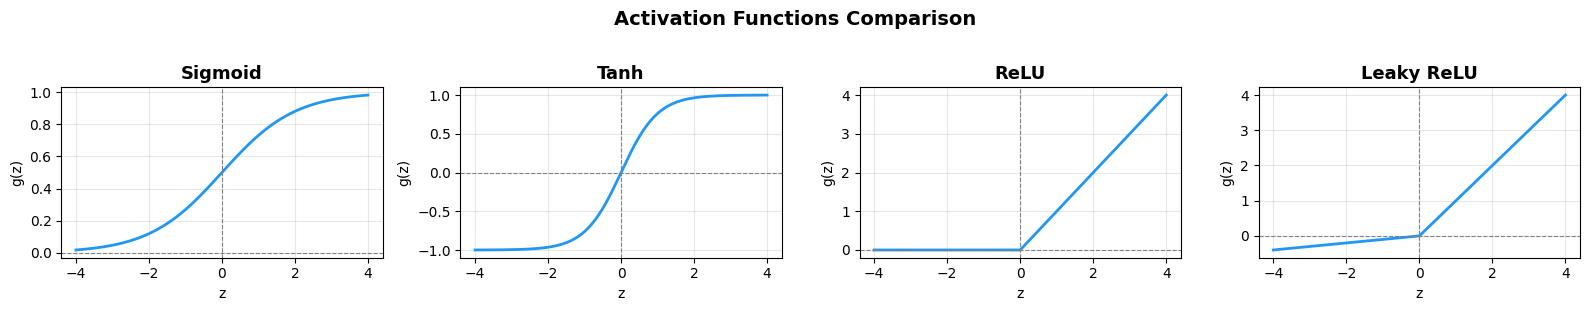

Input shape     : (3, 5)
After Layer 1   : (4, 5)
Output (sigmoid): (2, 5)
Sample output   :
 [[0.5 0.5 0.5]
 [0.5 0.5 0.5]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Activation Functions ──────────────────────────────────────────────────────
def sigmoid(z):   return 1 / (1 + np.exp(-z))
def tanh(z):      return np.tanh(z)
def relu(z):      return np.maximum(0, z)
def leaky_relu(z, alpha=0.1): return np.where(z > 0, z, alpha * z)

z = np.linspace(-4, 4, 400)
activations = {"Sigmoid": sigmoid(z), "Tanh": tanh(z),
               "ReLU": relu(z), "Leaky ReLU": leaky_relu(z)}

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, (name, values) in zip(axes, activations.items()):
    ax.plot(z, values, linewidth=2, color="#2196F3")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("z"); ax.set_ylabel("g(z)")
    ax.grid(alpha=0.3)

plt.suptitle("Activation Functions Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Forward pass of a simple 2-layer network ──────────────────────────────────
np.random.seed(42)
X = np.random.randn(3, 5)           # 5 examples, 3 features

W1 = np.random.randn(4, 3) * 0.01  # Layer 1: 4 neurons
b1 = np.zeros((4, 1))
W2 = np.random.randn(2, 4) * 0.01  # Layer 2: 2 neurons (output)
b2 = np.zeros((2, 1))

# Forward pass
Z1 = W1 @ X + b1                   # (4, 5)
A1 = relu(Z1)                      # (4, 5)
Z2 = W2 @ A1 + b2                  # (2, 5)
A2 = sigmoid(Z2)                   # (2, 5)  ← output probabilities

print("Input shape     :", X.shape)
print("After Layer 1   :", A1.shape)
print("Output (sigmoid):", A2.shape)
print("Sample output   :\n", np.round(A2[:, :3], 4))

<a name="gradient-descent"></a>
## 3. Gradient Descent Deep Dive

### Loss Landscape Intuition

Training = finding the **lowest point** in a high-dimensional loss landscape.

$$\theta^* = \arg\min_\theta \mathcal{L}(\theta)$$

### Gradient Descent Variants

| Variant | Batch Size | Update Frequency | Pros | Cons |
|---------|-----------|-----------------|------|------|
| **Batch GD** | Full dataset | Once per epoch | Stable, exact gradient | Slow for large data |
| **Stochastic GD (SGD)** | 1 example | Every example | Fast updates, online learning | Noisy, unstable |
| **Mini-Batch GD** | $m$ examples (32–512) | Every mini-batch | Best trade-off | Hyperparameter: batch size |

### The Update Rule

For any parameter $\theta$:

$$\theta \leftarrow \theta - \alpha \nabla_\theta \mathcal{L}(\theta)$$

Where:
- $\alpha$ is the **learning rate**
- $\nabla_\theta \mathcal{L}$ is the gradient of the loss w.r.t. $\theta$

### Learning Rate Selection

| $\alpha$ | Effect |
|----------|--------|
| Too large | Oscillates or diverges |
| Too small | Converges but very slowly |
| Just right | Smooth convergence |

**Learning rate schedules:**

$$\alpha_t = \frac{\alpha_0}{1 + \text{decay} \cdot t} \quad \text{(step decay)}$$
$$\alpha_t = \alpha_0 \cdot e^{-k t} \quad \text{(exponential decay)}$$
$$\alpha_t = \alpha_{\min} + \frac{1}{2}(\alpha_{\max} - \alpha_{\min})(1 + \cos(\frac{t}{T}\pi)) \quad \text{(cosine annealing)}$$

### Adaptive Optimizers

| Optimizer | Key Idea | Formula |
|-----------|----------|---------|
| **Momentum** | Accumulate velocity, dampen oscillations | $v = \beta v - \alpha \nabla \mathcal{L}$; $\theta \mathrel{+}= v$ |
| **RMSProp** | Divide by running avg of squared gradient | $s = \beta s + (1-\beta)(\nabla \mathcal{L})^2$; $\theta \mathrel{-}= \frac{\alpha}{\sqrt{s+\epsilon}} \nabla \mathcal{L}$ |
| **Adam** | Momentum + RMSProp | $\theta \mathrel{-}= \frac{\alpha \hat{m}}{\sqrt{\hat{v}}+\epsilon}$ |

**Adam** is the default choice for most deep learning tasks.

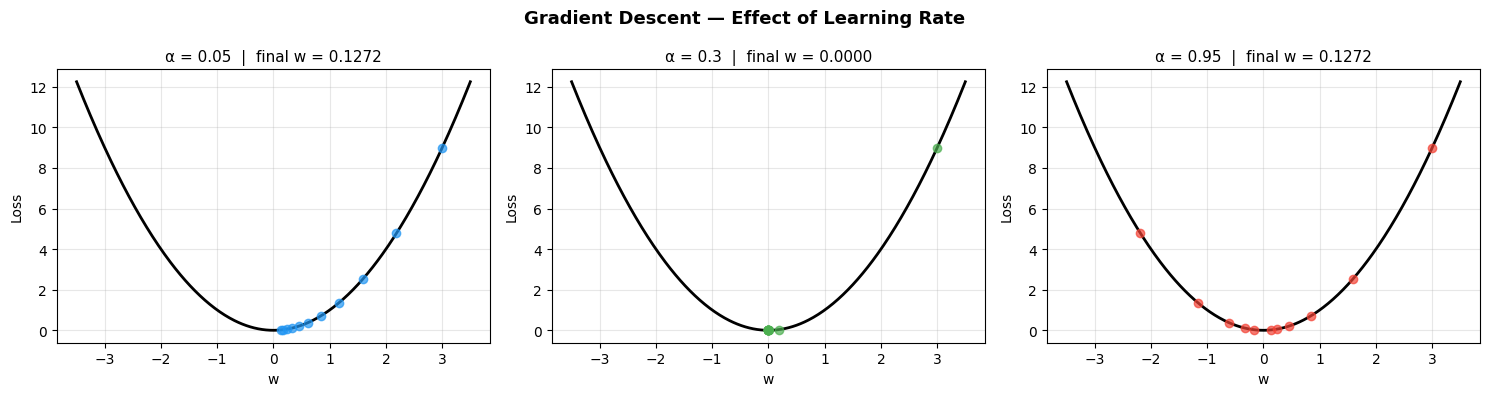

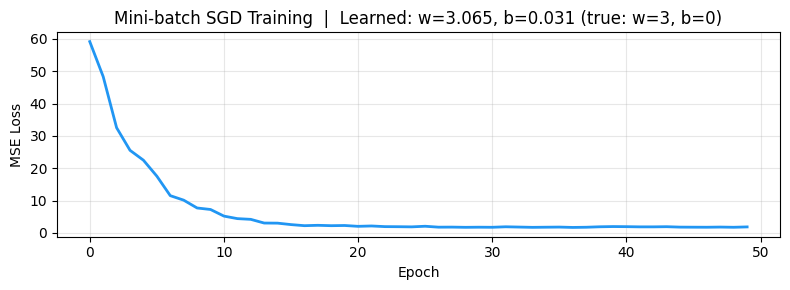

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Visualise gradient descent on a simple 2D loss surface ────────────────────
def loss(w):
    """Quadratic loss: L(w) = w^2 (minimum at 0)"""
    return w ** 2

def grad(w):
    return 2 * w

# Three learning rates
alphas = [0.05, 0.3, 0.95]
colors = ["#2196F3", "#4CAF50", "#F44336"]
w_init = 3.0
epochs = 30

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ws = np.linspace(-3.5, 3.5, 400)

for ax, alpha, color in zip(axes, alphas, colors):
    w, history = w_init, [w_init]
    for _ in range(epochs):
        w = w - alpha * grad(w)
        history.append(w)
    
    ax.plot(ws, loss(ws), "k-", linewidth=2, label="L(w) = w²")
    for h in history[::3]:
        ax.plot(h, loss(h), "o", color=color, markersize=6, alpha=0.7)
    ax.set_title(f"α = {alpha}  |  final w = {history[-1]:.4f}", fontsize=11)
    ax.set_xlabel("w"); ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)

plt.suptitle("Gradient Descent — Effect of Learning Rate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Mini-batch SGD demo ────────────────────────────────────────────────────────
np.random.seed(0)
X = np.random.randn(100, 1)
y = 3 * X.squeeze() + np.random.randn(100) * 0.5  # y = 3x + noise

w, b, lr, batch = 0.0, 0.0, 0.01, 16
losses = []

for epoch in range(50):
    idx = np.random.permutation(len(X))
    epoch_loss = 0
    for i in range(0, len(X), batch):
        xi = X[idx[i:i+batch]]
        yi = y[idx[i:i+batch]]
        pred = (w * xi.squeeze() + b)
        error = pred - yi
        dw = (2 / len(xi)) * (xi.squeeze() * error).sum()
        db = (2 / len(xi)) * error.sum()
        w -= lr * dw; b -= lr * db
        epoch_loss += (error ** 2).mean()
    losses.append(epoch_loss)

plt.figure(figsize=(8, 3))
plt.plot(losses, color="#2196F3", linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title(f"Mini-batch SGD Training  |  Learned: w={w:.3f}, b={b:.3f} (true: w=3, b=0)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

<a name="backpropagation"></a>
## 4. Backpropagation Explained

### The Chain Rule in Action

For a network with loss $\mathcal{L}$ and layers connected as $x \to z \to a \to \mathcal{L}$:

$$\frac{\partial \mathcal{L}}{\partial x} = \frac{\partial \mathcal{L}}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial x}$$

### Computational Graph

```
x ──[z = Wx+b]──> z ──[a = g(z)]──> a ──[L = loss(a,y)]──> L
     ↑                  ↑                   ↑
     W,b               g'(z)              dL/da
```

**Forward pass**: compute each node's value left → right.  
**Backward pass**: compute gradients right → left using the chain rule.

### Full Backprop Derivation (2-layer network)

**Forward pass:**
$$\mathbf{z}^{[1]} = \mathbf{W}^{[1]}\mathbf{x} + \mathbf{b}^{[1]}, \quad \mathbf{a}^{[1]} = g(\mathbf{z}^{[1]})$$
$$\mathbf{z}^{[2]} = \mathbf{W}^{[2]}\mathbf{a}^{[1]} + \mathbf{b}^{[2]}, \quad \hat{\mathbf{y}} = \sigma(\mathbf{z}^{[2]})$$
$$\mathcal{L} = -[y \log \hat{y} + (1-y) \log(1-\hat{y})]$$

**Backward pass (output layer):**
$$\delta^{[2]} = \hat{y} - y \quad \text{(for sigmoid + BCE)}$$
$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[2]}} = \delta^{[2]} (\mathbf{a}^{[1]})^T, \quad \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{[2]}} = \delta^{[2]}$$

**Backward pass (hidden layer):**
$$\delta^{[1]} = (\mathbf{W}^{[2]})^T \delta^{[2]} \odot g'(\mathbf{z}^{[1]})$$
$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[1]}} = \delta^{[1]} \mathbf{x}^T, \quad \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{[1]}} = \delta^{[1]}$$

### Vanishing and Exploding Gradients

During backprop through $L$ layers, gradients depend on products of weight matrices and activation derivatives:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[1]}} \propto \prod_{l=2}^{L} \mathbf{W}^{[l]} \cdot g'(\mathbf{z}^{[l]})$$

| Problem | Cause | Effect | Solution |
|---------|-------|--------|---------|
| **Vanishing** | $\|W\| < 1$ or $g' \approx 0$ (sigmoid saturation) | Early layers learn nothing | ReLU, residual connections, careful init |
| **Exploding** | $\|W\| > 1$ repeated | NaN weights | Gradient clipping, weight init |

XOR predictions vs truth:
  Input [0 0] → pred 0 (true 0)
  Input [0 1] → pred 0 (true 1)
  Input [1 0] → pred 1 (true 1)
  Input [1 1] → pred 0 (true 0)

Final loss: 0.34717


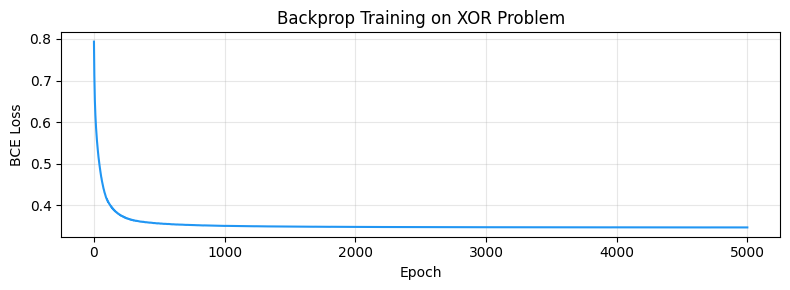

In [3]:
import numpy as np

# ── Backpropagation from scratch — binary classification ──────────────────────
np.random.seed(1)

# Toy XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float).T   # (2, 4)
y = np.array([[0, 1, 1, 0]], dtype=float)                # (1, 4)

def sigmoid(z):     return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def relu(z):        return np.maximum(0, z)
def relu_back(z):   return (z > 0).astype(float)

# Init weights (Xavier)
W1 = np.random.randn(4, 2) * np.sqrt(2/2)
b1 = np.zeros((4, 1))
W2 = np.random.randn(1, 4) * np.sqrt(2/4)
b2 = np.zeros((1, 1))

lr, epochs = 0.1, 5000
losses = []

for ep in range(epochs):
    # ── Forward ──────────────────────────────────────────────────────────────
    Z1 = W1 @ X + b1         # (4,4)
    A1 = relu(Z1)            # (4,4)
    Z2 = W2 @ A1 + b2        # (1,4)
    A2 = sigmoid(Z2)         # (1,4)  ← predictions

    m = X.shape[1]
    L = -(y * np.log(A2 + 1e-15) + (1-y) * np.log(1 - A2 + 1e-15)).mean()
    losses.append(L)

    # ── Backward ─────────────────────────────────────────────────────────────
    dA2 = -(y / (A2 + 1e-15)) + (1-y) / (1 - A2 + 1e-15)
    dZ2 = dA2 * A2 * (1 - A2)   # sigmoid derivative
    dW2 = dZ2 @ A1.T / m
    db2 = dZ2.sum(axis=1, keepdims=True) / m

    dA1 = W2.T @ dZ2
    dZ1 = dA1 * relu_back(Z1)
    dW1 = dZ1 @ X.T / m
    db1 = dZ1.sum(axis=1, keepdims=True) / m

    # ── Update ───────────────────────────────────────────────────────────────
    W2 -= lr * dW2; b2 -= lr * db2
    W1 -= lr * dW1; b1 -= lr * db1

# Evaluate
Z1 = W1 @ X + b1; A1 = relu(Z1)
Z2 = W2 @ A1 + b2; A2 = sigmoid(Z2)
preds = (A2 > 0.5).astype(int)

print("XOR predictions vs truth:")
for i in range(4):
    print(f"  Input {X[:,i].astype(int)} → pred {preds[0,i]} (true {int(y[0,i])})")
print(f"\nFinal loss: {losses[-1]:.5f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3))
plt.plot(losses, color="#2196F3", linewidth=1.5)
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.title("Backprop Training on XOR Problem")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

<a name="cnns"></a>
## 5. Convolutional Neural Networks (CNNs)

### Why Not Fully Connected for Images?

A $224 \times 224 \times 3$ image → $150,528$ inputs. A single FC layer with 1,000 neurons needs **150M parameters** — too many, poor generalization, no spatial awareness.

**Solution:** Exploit spatial structure with convolutions.

### The Convolution Operation

A filter/kernel $\mathbf{K} \in \mathbb{R}^{k \times k}$ slides over input $\mathbf{I}$:

$$(\mathbf{I} * \mathbf{K})[i,j] = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} \mathbf{I}[i+m, j+n] \cdot \mathbf{K}[m,n]$$

**Key properties:**
- **Spatial invariance**: same filter detects edges anywhere in the image
- **Parameter sharing**: one filter set shared across all positions
- **Local connectivity**: each output depends only on a small receptive field

### Controlling Output Dimensions

Given input $W \times H$, filter $k \times k$, padding $p$, stride $s$:

$$W_{\text{out}} = \left\lfloor \frac{W + 2p - k}{s} \right\rfloor + 1$$

| Padding | Effect |
|---------|--------|
| Valid (p=0) | Output smaller than input |
| Same | Output same size as input ($p = \lfloor k/2 \rfloor$) |

### CNN Components

| Component | Purpose | Operation |
|-----------|---------|-----------|
| **Conv Layer** | Detect features | Learnable filters → feature maps |
| **Pooling Layer** | Downsample | Max/Avg pool: translation invariance |
| **FC Layer** | Classify | Flatten + dense layers |
| **Activation (ReLU)** | Non-linearity | Applied after each conv |

### Feature Hierarchy

```
Layer 1 (shallow): Edges, gradients, colours
Layer 2 (mid):     Textures, patterns, corners  
Layer 3 (deep):    Parts (eyes, wheels, fur)
Layer N (final):   Object-level semantics
```

### A Complete CNN (example output dimensions)

```
Input:       (224, 224, 3)
Conv 7×7/2:  (112, 112, 64)     [filters learn edges]
MaxPool 3×3: (56, 56, 64)
Conv 3×3:    (56, 56, 128)      [filters learn textures]
MaxPool 3×3: (28, 28, 128)
Conv 3×3:    (28, 28, 256)
AdapAvgPool: (1, 1, 256)        [global average pooling]
FC + Softmax: (num_classes,)
```

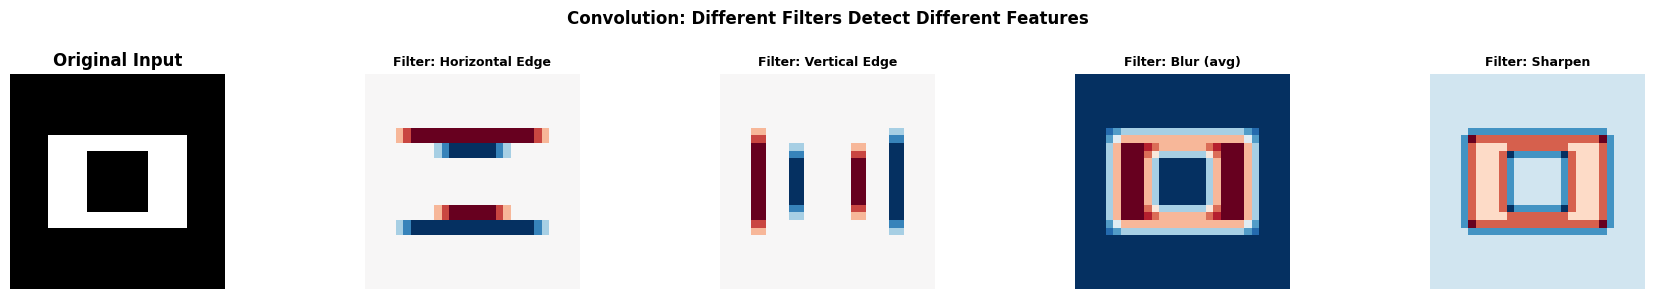

Output size formula: floor((W + 2p - k) / s) + 1

  Same padding        : 224×224 → 224×224  (k=3, p=1, s=1)
  Valid padding       : 224×224 → 222×222  (k=3, p=0, s=1)
  Stride-2            : 224×224 → 112×112  (k=3, p=1, s=2)
  7×7 stride-2        : 224×224 → 112×112  (k=7, p=3, s=2)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ── Manual 2D convolution ──────────────────────────────────────────────────────
def conv2d(image, kernel, stride=1, padding=0):
    """Single-channel 2D convolution."""
    if padding > 0:
        image = np.pad(image, padding, mode="constant")
    H, W = image.shape
    k = kernel.shape[0]
    out_h = (H - k) // stride + 1
    out_w = (W - k) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = image[i*stride:i*stride+k, j*stride:j*stride+k]
            out[i, j] = (region * kernel).sum()
    return out

# Create a simple image
np.random.seed(0)
img = np.zeros((28, 28))
img[8:20, 5:23] = 1   # white rectangle
img[10:18, 10:18] = 0  # hole

# Several hand-crafted filters
filters = {
    "Horizontal Edge": np.array([[-1,-1,-1],[0,0,0],[1,1,1]]),
    "Vertical Edge":   np.array([[-1,0,1],[-1,0,1],[-1,0,1]]),
    "Blur (avg)":      np.ones((3,3)) / 9,
    "Sharpen":         np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("Original Input", fontweight="bold")
axes[0].axis("off")

for ax, (name, k) in zip(axes[1:], filters.items()):
    feature_map = conv2d(img, k, padding=1)
    ax.imshow(feature_map, cmap="RdBu_r")
    ax.set_title(f"Filter: {name}", fontsize=9, fontweight="bold")
    ax.axis("off")

plt.suptitle("Convolution: Different Filters Detect Different Features", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

# ── Output size formula demo ──────────────────────────────────────────────────
print("Output size formula: floor((W + 2p - k) / s) + 1\n")
configs = [
    ("Same padding",  224, 3, 1, 1),
    ("Valid padding", 224, 3, 0, 1),
    ("Stride-2",      224, 3, 1, 2),
    ("7×7 stride-2",  224, 7, 3, 2),
]
for name, W, k, p, s in configs:
    out = (W + 2*p - k) // s + 1
    print(f"  {name:20s}: {W}×{W} → {out}×{out}  (k={k}, p={p}, s={s})")

<a name="training-strategies"></a>
## 6. Training Deep Networks: Strategies and Best Practices

### Weight Initialization

Poor initialization → vanishing/exploding gradients from the first forward pass.

| Init Strategy | Formula | Best For |
|--------------|---------|---------|
| **Zero init** | $W = 0$ | ❌ Symmetry breaking fails — never use |
| **Random Normal** | $W \sim \mathcal{N}(0, 0.01)$ | Shallow nets only |
| **Xavier / Glorot** | $W \sim \mathcal{N}\!\left(0, \sqrt{\frac{2}{n_{in}+n_{out}}}\right)$ | tanh, sigmoid activations |
| **He / Kaiming** | $W \sim \mathcal{N}\!\left(0, \sqrt{\frac{2}{n_{in}}}\right)$ | ReLU and variants ✅ |

### Regularization Techniques

**L2 Regularization (Weight Decay):**
$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \frac{\lambda}{2m} \sum_{l} \|\mathbf{W}^{[l]}\|_F^2$$

**L1 Regularization (promotes sparsity):**
$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \frac{\lambda}{m} \sum_{l} \|\mathbf{W}^{[l]}\|_1$$

**Dropout**: At each training step, randomly zero out neurons with probability $p$:  
- Prevents co-adaptation: no neuron can rely on other specific neurons
- Scales activations at test time: multiply by $(1-p)$ (or use inverted dropout)

**Early Stopping**: Stop training when validation loss stops improving — implicit regularization.

### Batch Normalization

Normalizes layer inputs, reducing **internal covariate shift**:

$$\hat{x}^{(i)} = \frac{x^{(i)} - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$
$$y^{(i)} = \gamma \hat{x}^{(i)} + \beta$$

Where $\gamma, \beta$ are learned scale and shift parameters.

**Benefits:**
- Allows much higher learning rates (faster training)
- Acts as mild regularization
- Reduces sensitivity to weight initialization

### Data Augmentation

Create new training examples by applying **label-preserving transformations**:

| Technique | Example |
|-----------|---------|
| Random crop | 224×224 crop from 256×256 |
| Horizontal flip | Mirror image left-right |
| Color jitter | Adjust brightness, contrast, saturation |
| Rotation | ±15° random rotation |
| Cutout / Mixup | Advanced: erase patches or blend images |

### Hyperparameter Tuning Strategy

1. **Coarse grid search** over $\log$-scale ranges (e.g., $\alpha \in \{10^{-4}, 10^{-3}, 10^{-2}\}$)
2. **Random search** is generally better than grid search in high dimensions
3. **Bayesian optimization** for expensive experiments
4. Use **validation set** (not test set) to evaluate configurations

Inverted dropout: test output ≈ average of train outputs?
  Test output (no dropout):     [0.997  0.3692 0.5043 0.3303 0.9813]
  Avg of 50 dropout runs:       [0.7361 0.4082 0.5311 0.4279 0.714 ]


C:\Users\Javad\AppData\Local\Temp\ipykernel_3720\1467481320.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(X_raw, labels=[f"f{i+1}" for i in range(4)])
C:\Users\Javad\AppData\Local\Temp\ipykernel_3720\1467481320.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(X_bn, labels=[f"f{i+1}" for i in range(4)])


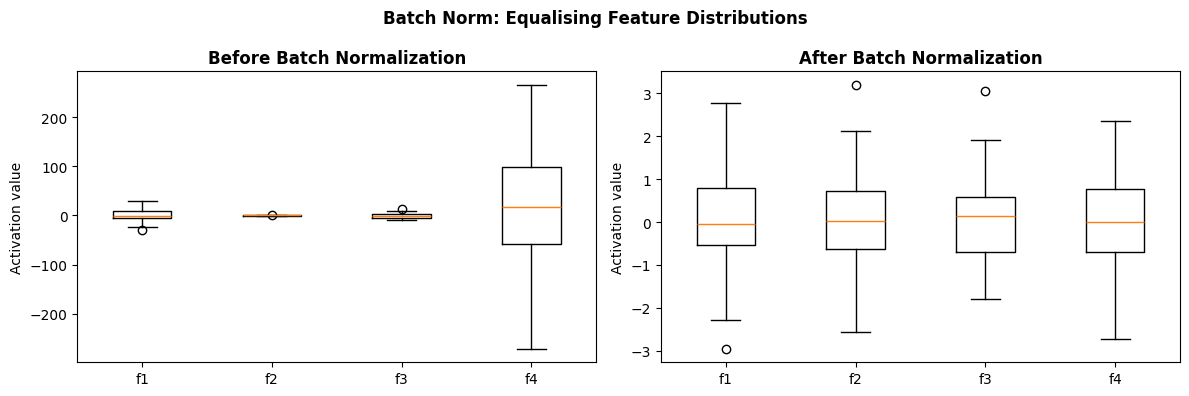

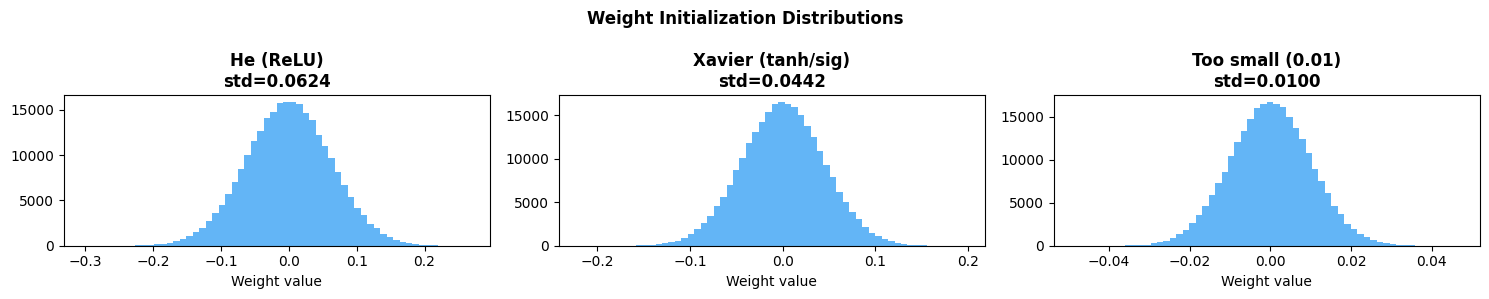

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ── Effect of Dropout on training vs test ──────────────────────────────────────
np.random.seed(0)

def forward_with_dropout(x, W1, b1, W2, b2, drop_p=0.5, training=True):
    Z1 = W1 @ x + b1
    A1 = np.maximum(0, Z1)
    if training:
        mask = (np.random.rand(*A1.shape) > drop_p)
        A1 = A1 * mask / (1 - drop_p)   # inverted dropout
    Z2 = W2 @ A1 + b2
    return 1 / (1 + np.exp(-Z2))

W1 = np.random.randn(8, 2); b1 = np.zeros((8,1))
W2 = np.random.randn(1, 8); b2 = np.zeros((1,1))
x  = np.random.randn(2, 10)

train_outputs = [forward_with_dropout(x, W1, b1, W2, b2, training=True) for _ in range(50)]
test_output   = forward_with_dropout(x, W1, b1, W2, b2, training=False)

avg_train = np.mean(train_outputs, axis=0)
print("Inverted dropout: test output ≈ average of train outputs?")
print(f"  Test output (no dropout):     {test_output[0,:5].round(4)}")
print(f"  Avg of 50 dropout runs:       {avg_train[0,:5].round(4)}")

# ── Batch Normalization demo ───────────────────────────────────────────────────
def batch_norm(X, gamma=1, beta=0, eps=1e-8):
    mu = X.mean(axis=0, keepdims=True)
    var = X.var(axis=0, keepdims=True)
    X_hat = (X - mu) / np.sqrt(var + eps)
    return gamma * X_hat + beta, mu, var

X_raw = np.random.randn(100, 4) * np.array([10, 0.1, 5, 100])  # very different scales
X_bn, mu, var = batch_norm(X_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(X_raw, labels=[f"f{i+1}" for i in range(4)])
axes[0].set_title("Before Batch Normalization", fontweight="bold")
axes[0].set_ylabel("Activation value")

axes[1].boxplot(X_bn, labels=[f"f{i+1}" for i in range(4)])
axes[1].set_title("After Batch Normalization", fontweight="bold")
axes[1].set_ylabel("Activation value")

plt.suptitle("Batch Norm: Equalising Feature Distributions", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

# ── He vs Xavier initialisation ────────────────────────────────────────────────
n_in = 512
he_weights    = np.random.randn(n_in, n_in) * np.sqrt(2/n_in)
xavier_weights= np.random.randn(n_in, n_in) * np.sqrt(2/(n_in+n_in))
tiny_weights  = np.random.randn(n_in, n_in) * 0.01

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, (label, W) in zip(axes, [("He (ReLU)", he_weights), 
                                   ("Xavier (tanh/sig)", xavier_weights), 
                                   ("Too small (0.01)", tiny_weights)]):
    ax.hist(W.flatten(), bins=60, color="#2196F3", alpha=0.7, edgecolor="none")
    ax.set_title(f"{label}\nstd={W.std():.4f}", fontweight="bold")
    ax.set_xlabel("Weight value")

plt.suptitle("Weight Initialization Distributions", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

<a name="architectures"></a>
## 7. Seminal CNN Architectures and Design Principles

| Architecture | Year | Depth | Params | Top-5 Error | Key Innovation |
|-------------|------|-------|--------|-------------|----------------|
| **LeNet-5** | 1998 | 7 | 60K | — | First CNN for digit recognition |
| **AlexNet** | 2012 | 8 | 60M | 15.3% | ReLU, Dropout, GPU training |
| **VGG-16** | 2014 | 16 | 138M | 7.3% | Deep uniform 3×3 convolutions |
| **GoogLeNet** | 2014 | 22 | 6.8M | 6.7% | Inception module (parallel branches) |
| **ResNet-50** | 2015 | 50 | 25M | 3.6% | Skip/residual connections |

### LeNet-5 (1998) — The Pioneer

```
Input (32×32) → Conv5×5 → Pool → Conv5×5 → Pool → FC → FC → Softmax
```
Trained on MNIST; proved CNNs work for document recognition.

### AlexNet (2012) — The Revolution

Key contributions:
1. **ReLU** instead of tanh → faster training
2. **Dropout** (0.5) in FC layers → regularization
3. **Data augmentation** (crops + flips) → 2,048x more data
4. **GPU training** (dual GTX 580)

### VGG-16 (2014) — The Power of Simplicity

> Two $3 \times 3$ convolutions have the same receptive field as one $5 \times 5$ conv, but with **fewer parameters and more non-linearity**.

$$3\times3 + 3\times3 = 2 \times 9 = 18 \text{ params per channel}$$
$$5\times5 = 25 \text{ params per channel}$$

### GoogLeNet / Inception (2014) — Parallel Pathways

The Inception module applies $1 \times 1$, $3 \times 3$, $5 \times 5$ convolutions and max pooling **in parallel**, then concatenates:

```
           ┌─── 1×1 conv ──────────────┐
input  ────┼─── 1×1 conv → 3×3 conv ──┼──→ concat → next layer
           ├─── 1×1 conv → 5×5 conv ──┤
           └─── MaxPool → 1×1 conv ───┘
```

The $1 \times 1$ convolutions act as **bottlenecks** — cheap channel reduction before expensive large convolutions.

### ResNet (2015) — Solving Degradation with Skip Connections

**Problem**: deeper networks performed *worse* than shallower ones (not overfitting — degradation).

**Solution**: The residual / skip connection:

$$\mathbf{y} = \mathcal{F}(\mathbf{x}, \{W_i\}) + \mathbf{x}$$

The network learns the **residual** $\mathcal{F}(\mathbf{x}) = \mathbf{y} - \mathbf{x}$ rather than the full mapping.

If the optimal mapping is close to identity, it's easy to learn $\mathcal{F} \approx 0$.

```
x ──────────────────────────────┐
│                               + ──→ ReLU ──→ output
└── Conv → BN → ReLU → Conv → BN ──┘
```

**Why ResNets are crucial:**
- Enable training of 100s/1000s of layers
- Gradient flows directly through skip connections
- Foundation for nearly all modern architectures (ResNet, EfficientNet, ViT)

### Key Design Principles Summary

| Principle | Embodied In |
|-----------|-------------|
| Use small filters (3×3) | VGG, ResNet |
| Reduce channels cheaply (1×1) | Inception, ResNet bottleneck |
| Skip connections for deep nets | ResNet, DenseNet |
| Depthwise separable convs | MobileNet, EfficientNet |
| Attention over feature maps | SENet, EfficientNet |

---
## ✅ Course 1 Key Takeaways

- Neural networks are **function approximators** built from weighted sums + non-linearities
- **Backpropagation** = chain rule applied to computational graphs
- **Gradient descent** (especially Adam) finds optimal weights iteratively
- **CNNs** exploit spatial structure: local connectivity + weight sharing
- **Residual connections** unlock arbitrarily deep networks
- **Batch norm + He init + Dropout** = the standard training toolkit